# Sales Forecasting Using Advertising Data
### Python Linear Regression Model - OLS

**Name:** *Kabir Tandon* and *Parth Thakur*  
**Register Number:** *2333428* and *2333437*  
**Course:** *Data Analysis using Python*  
**Software Used:** Python (VS Code)  






## Objective of the Project 

The objective of this project is to build a simple Linear Regression model using Python on VS code to understand how advertising expenditure through various means, such as TV ads, affects sales.

We use advertising data consisting of:
- Money spent on TV advertising. 
- Money spent on Radio advertising. 
- Money spent on Newspaper advertising.

We are trying to analyse the relationship between advertising and sales and predict sales using regression analysis.


## Step 1 - Importing Required Libraries

In this project, we use the following Python libraries:

- **Pandas (pd)** → for data handling and dataset operations  
- **Matplotlib (plt)** → for creating graphs and basic visualisations  
- **Seaborn (sns)** → for advanced statistical visualisation and normality plots  
- **Statsmodels (sm)** → to build and analyse the Linear Regression (OLS) model  

These libraries help us load the dataset, visualise relationships between variables, and build a regression model to predict sales based on advertising expenditure.



In [7]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

print("Libraries imported successfully")


Libraries imported successfully


## Step 2 - Loading the Dataset

We use an advertising dataset that contains spending on:
- TV advertising
- Radio advertising
- Newspaper advertising

The dependent variable is **Sales**, which represents product sales.

The dataset helps us understand how advertising spending impacts sales and which medium contributes most.


In [8]:
data = pd.read_csv("Advertising_CIA_Py.csv")

print("Dataset Preview:")
display(data.head(200))


Dataset Preview:


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


### Understanding the Dataset

The dataset contains advertising expenditure across three media channels: TV, Radio, and Newspaper.  
The dependent variable is Sales, which represents product sales generated.
This dataset will be used to examine the relationship between advertising expenditure and sales using Multiple Linear Regression.  
We will also visualise the relationships and check the distribution of variables before building the model.


## Step 3- Correlation Matrix

A correlation matrix helps us understand the strength and direction of relationships 
between all variables in the dataset.

Correlation values range from:
- +1 → Strong positive relationship
-  0 → No relationship
- -1 → Strong negative relationship

This helps us see how strongly advertising variables are related to sales 
before interpreting the regression model.

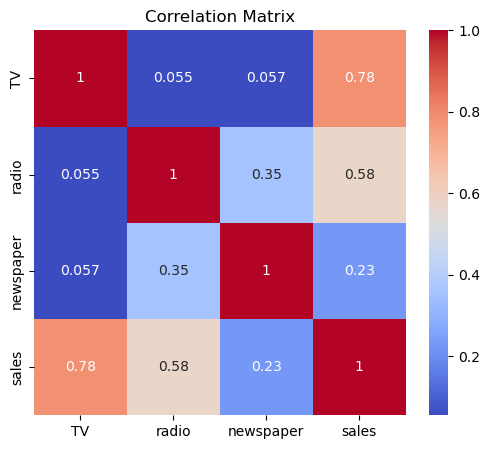

In [12]:
# Correlation matrix
corr_matrix = data[["TV", "radio", "newspaper", "sales"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Step 4 – Building the Multiple Linear Regression Model

In this step, we build a Multiple Linear Regression model using the OLS (Ordinary Least Squares) method.

Dependent Variable:
- Sales (represents product sales)

Independent Variables:
- TV advertising expenditure
- Radio advertising expenditure
- Newspaper advertising expenditure

The model helps us understand how changes in advertising spending across different media impact sales.

In [10]:
# Define dependent and independent variables
X = data[["TV", "radio", "newspaper"]]   # independent variables
Y = data["sales"]                        # dependent variable

# Add constant (intercept)
import statsmodels.api as sm
X = sm.add_constant(X)

# Build regression model
model = sm.OLS(Y, X).fit()

# Show regression results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           1.58e-96
Time:                        10:46:28   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

## Step 5 – Data Visualisation

Before interpreting the regression model, we visualise the relationship between advertising expenditure and sales.

Visualisations included:
- Scatter plots between each advertising medium and sales
- Total advertising vs sales
- Bar chart of average spending
- Pie chart of advertising share
- Normality distribution of sales

These graphs help us understand trends and relationships in the dataset.

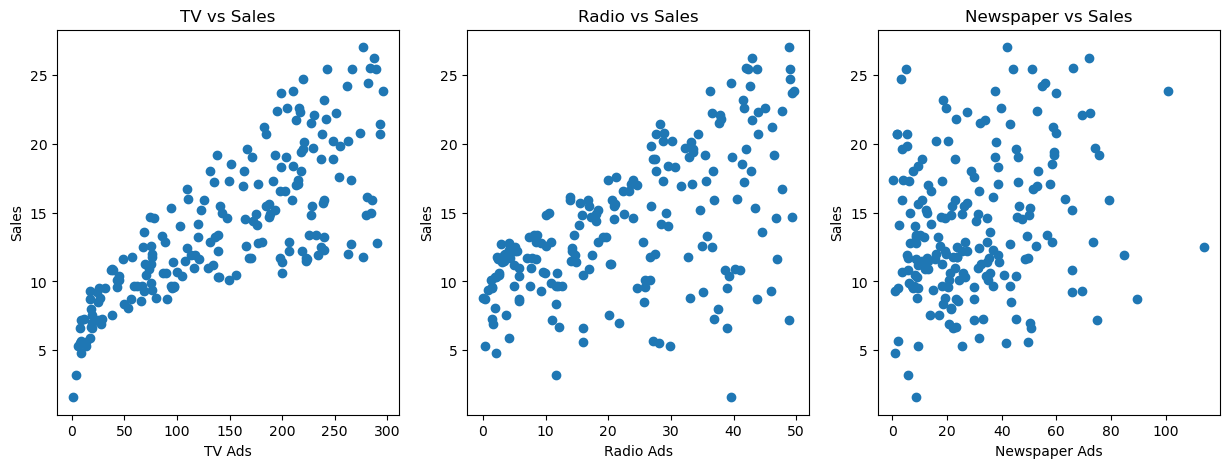

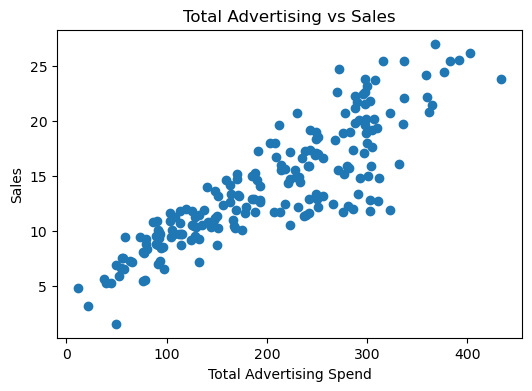

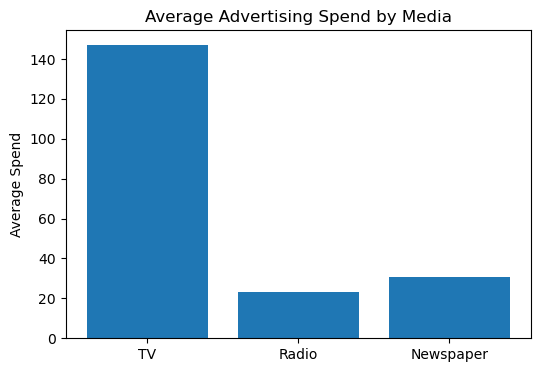

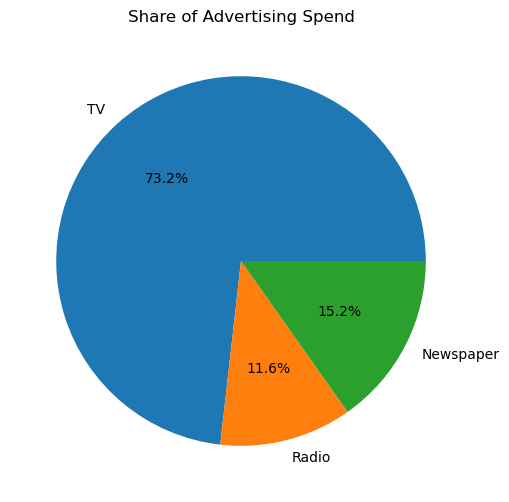

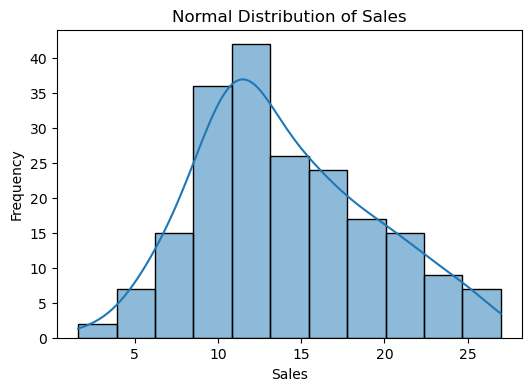

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Scatter plots ----------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(data["TV"], data["sales"])
plt.title("TV vs Sales")
plt.xlabel("TV Ads")
plt.ylabel("Sales")

plt.subplot(1,3,2)
plt.scatter(data["radio"], data["sales"])
plt.title("Radio vs Sales")
plt.xlabel("Radio Ads")
plt.ylabel("Sales")

plt.subplot(1,3,3)
plt.scatter(data["newspaper"], data["sales"])
plt.title("Newspaper vs Sales")
plt.xlabel("Newspaper Ads")
plt.ylabel("Sales")

plt.show()


# ---------- TOTAL ADS vs SALES ----------
data["Total_Ads"] = data["TV"] + data["radio"] + data["newspaper"]

plt.figure(figsize=(6,4))
plt.scatter(data["Total_Ads"], data["sales"])
plt.title("Total Advertising vs Sales")
plt.xlabel("Total Advertising Spend")
plt.ylabel("Sales")
plt.show()


# ---------- BAR GRAPH ----------
avg_spend = [data["TV"].mean(), data["radio"].mean(), data["newspaper"].mean()]
labels = ["TV", "Radio", "Newspaper"]

plt.figure(figsize=(6,4))
plt.bar(labels, avg_spend)
plt.title("Average Advertising Spend by Media")
plt.ylabel("Average Spend")
plt.show()


# ---------- PIE CHART ----------
total_spend = [data["TV"].sum(), data["radio"].sum(), data["newspaper"].sum()]

plt.figure(figsize=(6,6))
plt.pie(total_spend, labels=labels, autopct='%1.1f%%')
plt.title("Share of Advertising Spend")
plt.show()


# ---------- NORMALITY CURVE ----------
plt.figure(figsize=(6,4))
sns.histplot(data["sales"], kde=True)
plt.title("Normal Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


## Step 6 – Interpretation of Results

1. Overall Model Performance

The R-squared value obtained from the regression model is high (around 0.89), which indicates that approximately 89% of the variation in sales is explained by the independent variables (TV, Radio, and Newspaper advertising).
This suggests that advertising expenditure is a strong predictor of product sales and the model has good explanatory power.

2. Relationship Between Advertising and Sales

The scatter plots and regression results show a clear positive relationship between advertising expenditure and sales:

TV Advertising:
TV advertising has the strongest positive relationship with sales.
The correlation matrix shows a high correlation (≈ 0.78) between TV advertising and sales, indicating that increased spending on TV advertisements significantly increases sales.
The regression coefficient for TV is also the highest, confirming that TV advertising is the most influential variable in predicting sales.

Radio Advertising:
Radio advertising also shows a moderate positive relationship with sales.
The correlation coefficient between radio and sales is around 0.58, suggesting that increased radio advertising contributes to higher sales, but its impact is weaker than TV advertising.

Newspaper Advertising:
Newspaper advertising has the weakest relationship with sales among the three media.
The correlation between newspaper advertising and sales is relatively low (≈ 0.23), indicating that newspaper advertisements contribute less significantly to sales compared to TV and radio.

3. Correlation Between Independent Variables

The correlation matrix also helps us understand relationships among the independent variables:

TV and radio advertising show very low correlation with each other, meaning they influence sales independently.

Newspaper advertising has weak to moderate correlation with radio but low correlation with TV.

Since correlations among independent variables are not very high, there is no serious multicollinearity issue in the model.

This ensures that the regression results are reliable and each variable contributes uniquely to explaining sales.

4. Total Advertising vs Sales Relationship

The combined advertising expenditure (TV + Radio + Newspaper) plotted against sales shows a strong positive trend.
This indicates that as total advertising spending increases, sales generally increase as well.
The aggregate scatter plot further confirms the overall effectiveness of advertising in driving sales.

5. Normality and Distribution Insights

The histogram and normality curve of sales indicate that the data is reasonably distributed without extreme skewness.
This supports the reliability of the regression model and suggests that the assumptions of linear regression are reasonably satisfied.

Final Conclusion

This project demonstrates that advertising expenditure plays a significant role in determining product sales. Among all advertising media:

TV advertising is the most effective in increasing sales.

Radio advertising has a moderate positive impact.

Newspaper advertising has the least impact on sales.

The high R-squared value and strong correlations confirm that the regression model is effective in explaining and predicting sales based on advertising expenditure.
Therefore, companies aiming to maximise sales should focus more on TV and radio advertising while optimising expenditure on newspaper advertising.
